<a href="https://colab.research.google.com/github/romitchavan/Netflix-Content-Analysis/blob/main/notebooks/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Netflix Exploratory Data Analysis (EDA)**

## Project Objective

The objective of this project is to analyze Netflix content data to discover patterns related to content distribution, viewer engagement, ratings, genres, and release trends.

This project includes:
*   Data Cleaning
*   Feature Engineering
*   Data visualization
*   Business Insights

## Importing Required Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [11]:
df = pd.read_csv("../data/netflix_titles_dataset.csv")

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Basic Dataset Inspection

Helps to understand:
- dataset size
- column names
- data types
- missing values

In [12]:
df.shape

(8807, 12)

In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [15]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Data Cleaning

In this section:
- Missing values are checked
- Duplicate rows are removed
- Data types are corrected
- Column names are standardized

#### Check missing values

In [16]:

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Remove duplicated values

In [17]:
df.drop_duplicates(inplace=True)

### Handle missing values and bad values

In [18]:
# Filling null values with 'Unknown' because dropping them will affect data analysis
df['director'] = df['director'].fillna('Unknown')

In [19]:
# Filling null values with 'Not Available'
df['cast'] = df['cast'].fillna('Not Available')

In [20]:
# Filling null values 'Unknown'
df['country'] = df['country'].fillna('Unknown')

In [21]:
# Nullify the bad values as there are only few bad values in rating column
values = ['66 min', '74 min', '84 min']
df['rating'] = df['rating'].replace(values, np.nan)

# Filling the null values with mode
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [22]:
# Filling the null values with mode
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [23]:
mask = (df['date_added'].notna() & pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce').isna())

df.loc[mask, ['date_added']]

,date_added
6079,"August 4, 2017"
6177,"December 23, 2018"
6213,"December 15, 2018"
6279,"July 1, 2017"
6304,"July 26, 2019"
...,...
8539,"January 8, 2018"
8557,"December 25, 2015"
8684,"August 1, 2017"
8712,"March 31, 2017"


In [24]:
df.loc[mask, 'date_added'] = pd.to_datetime(df.loc[mask, 'date_added'], errors='coerce' ).dt.strftime('%B %d, %Y')

In [25]:
# Handled bad and null date
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

#Converting to date time format
df['date_added'] = pd.to_datetime(df['date_added'])

## Feature Engineering

In [26]:
# Extract Year Added
df['year_added'] = df['date_added'].dt.year



*   Helps analyze Netflix content growth over years
*   Useful for trend analysis



### Exploratory Data Analysis

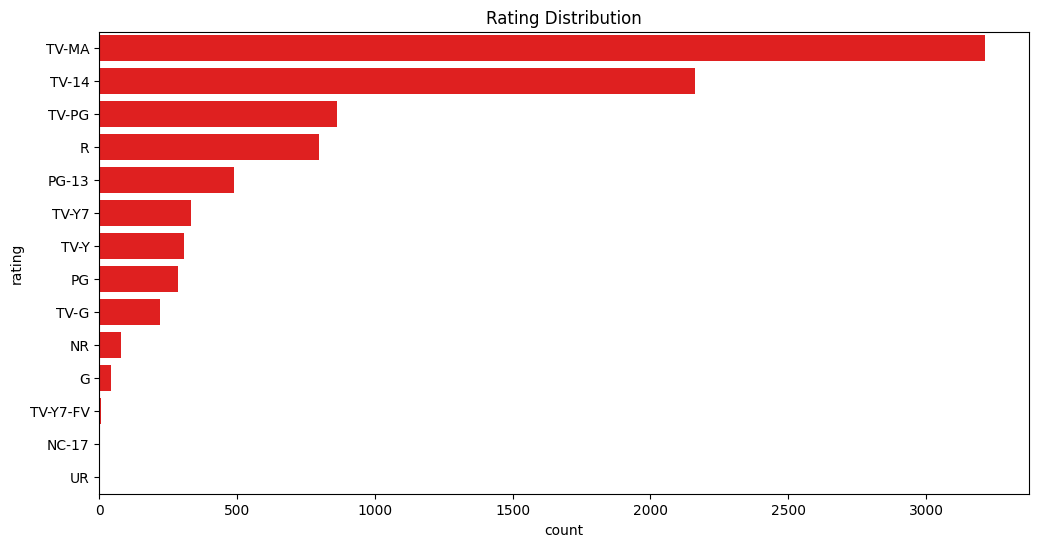

In [27]:
plt.figure(figsize=(12,6))
sns.countplot(y = "rating" , data=df ,  order=df["rating"].value_counts().index ,color="#FF0000")
plt.title('Rating Distribution')
plt.show()



1.   TV-MA is Netflix's highest rating category shows that Netflix is premium adult content platform
2.   Netflix has significantly lower PG and family-friendly content compared to competitors like Disney+. If Netflix aims to expand its subscriber base to family and younger demographics, investing in PG-rated content could be a strategic growth lever
(Deeper analysis is needed based on viewership hours, subscriber growth, and regional data to confirm this as a strategic gap.)



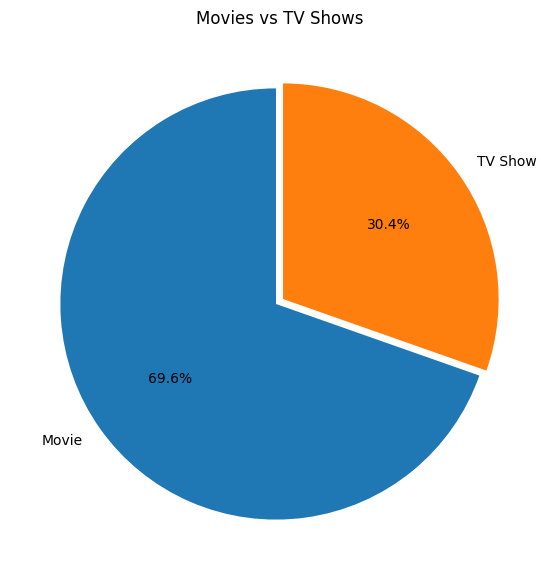

In [28]:
counts = df['type'].value_counts()
label = counts.index
size_of_slice = counts.values

plt.figure(figsize=(7,7))
plt.pie(size_of_slice,labels = label,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.02, 0.02)
)
plt.title('Movies vs TV Shows')
plt.show()

More movies than TV shows that indicates despite TV shows being a major growth driver for engagement, movies still dominate by volume

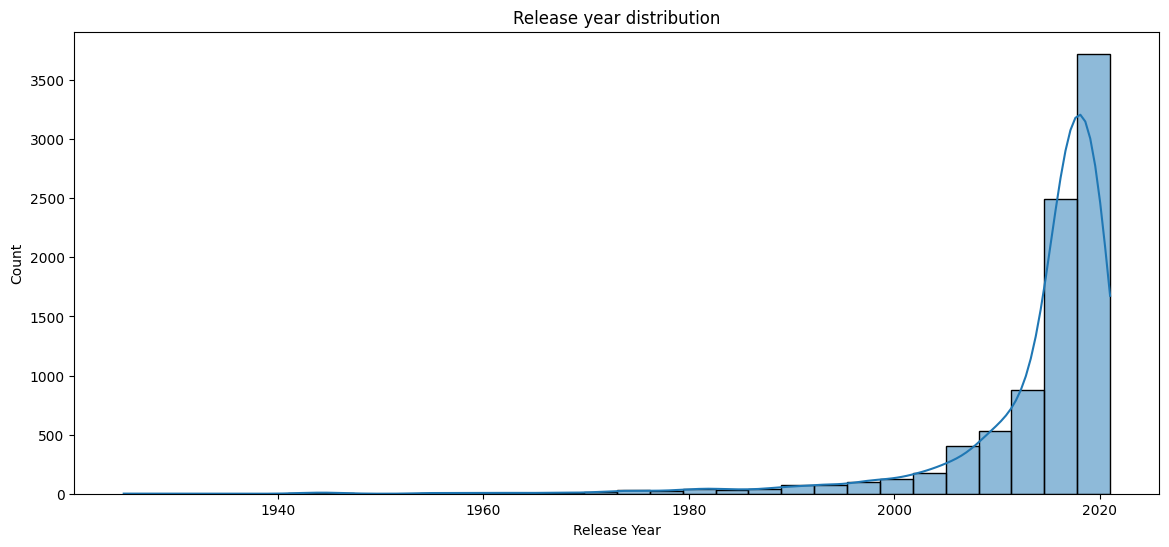

In [29]:
plt.figure(figsize=(14,6))
sns.histplot(df["release_year"], bins=30, kde=True)
plt.title('Release year distribution')
plt.xlabel('Release Year')
plt.show()

*   Netflix's content library grew modestly until 2009, after which releases accelerated sharply, driven by the streaming era, original productions, and global expansion.
*   2009–2010 marks the turning point, coinciding with Netflix's global streaming rollout and licensing deals.



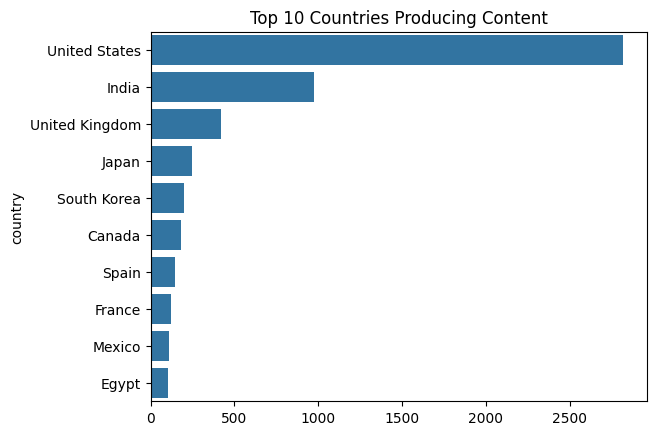

In [30]:
top_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Content")
plt.show()



*   Content production is heavily dominated by the USA, followed by India and the UK, reflecting the influence of Hollywood and Bollywood industries.
*   The strong presence of Japan and South Korea highlights the growing global demand for Asian content, particularly anime and K-dramas.



#**Final insights**



1.   **Content Production by Country**        
The US leads global Netflix content, backed by Hollywood's scale, followed by India (Bollywood) and the UK. Japan and South Korea represent the Asian content boom driven by anime and K-dramas. Spain and France bring European storytelling, while Canada's cultural proximity to the US boosts its output. Mexico and Egypt signal Netflix's push into Latin American and Middle Eastern markets, reflecting a deliberate global diversification strategy.

2.   **Content Growth Over the Years**                                            
Netflix's library grew slowly until 2009, after which it exploded — driven by the shift from DVD to streaming, launch of Netflix Originals (2013), and aggressive global expansion. The bulk of the catalog is post-2010, meaning classic/older content remains a significant gap in the library.

3.   **Content Type Distribution**                                                                   
Movies dominate at 69.6% vs TV Shows at 30.4% — a 2:1 ratio. While Netflix acquires more films by volume, TV shows likely drive higher engagement per title due to multi-season binge behaviour. The strategy leans on breadth (movies) while depth (series) drives retention.

4.   **Ratings Distribution**                                                       
Netflix is fundamentally an adult-first platform:
*   TV-MA dominates both movies and TV shows — thrillers, crime dramas, prestige originals are the core identity
*   TV-14 is a strong second — covering teen dramas, sci-fi, and reality content
*   Family/kids content (TV-PG, TV-G, TV-Y) is severely underrepresented — a clear gap vs Disney+

5.   **Top Genres on Netflix**  
*   International Movies and International TV Shows together occupy two of the top 5 spots — confirming that non-English content is not a niche but a core pillar of Netflix's identity. This directly aligns with the country insight — India, Japan, South Korea, Spain, and France are not just producing content, their content is actively being consumed globally.

*   Dramas dominate as the #1 narrative genre, spanning both film and series formats. Combined with TV Dramas at #7, drama in its various forms is essentially Netflix's backbone — consistent with the TV-MA rating dominance, since prestige adult drama is what defines Netflix Originals

*   Comedies at #3 show that while Netflix skews serious and mature, there's strong demand for lighter content — suggesting a balanced emotional palette across the catalog.